<div style="display:flex;align-items:center;justify-content:space-between;border-bottom:2px solid #c8962d;padding-bottom:12px;margin-bottom:20px">
  <div><strong>Universidad Externado de Colombia</strong><br>
  <span>Programa de Ciencia de Datos · Machine Learning II</span><br>
  <span>Docente: Wilmer Pineda-Ríos</span></div>
</div>

# Proyecto Integrador — Segunda Entrega
## Predicción de Precios de Criptomonedas en Pesos Colombianos (USD/COP)

**Integrantes:** Julian Duarte · Julian Jimenez  
**Artículo Base:** Gautam, M. (2025). *Crypto Price Prediction Using LSTM+XGBoost*. arXiv:2506.22055v1 [cs.LG].  
**Fase 2:** Obtención de Datos en Vivo, Auditoría & Limpieza, Ingeniería de Variables, Pipeline sin Fuga, Optimización de Hiperparámetros, Comparación con Series de Tiempo (ARIMA/Prophet) y Despliegue.

---

## Pregunta problema

> **¿Qué tan bien pueden los modelos avanzados de Machine Learning II (XGBoost, Random Forest, LightGBM) y los modelos clásicos de series de tiempo (ARIMA / AutoARIMA) predecir el precio de cierre a corto plazo (1 hora) en pesos colombianos (COP) de una canasta de criptomonedas (BTC, ETH, DOGE), reemplazando la extracción secuencial del LSTM del paper base por ingeniería explícita de variables temporales y garantizando un flujo reproducible sin fuga de información?**

---

## Protocolo acordado antes de modelar

- **Unidad de Análisis:** Velas de 1 hora por criptomoneda ($N \ge 17.000$ registros).
- **Variable Objetivo ($y_{t+1}$):** Precio de Cierre en Pesos Colombianos a 1 hora adelante ($\text{Close}_{t+1}^{\text{COP}} = \text{Close}_{t+1}^{\text{USD}} \times \text{TRM}_{t+1}$).
- **Métrica Principal de Evaluación:** **MAPE** (Mean Absolute Percentage Error), interpretable para decisiones financieras.
- **Métrica Secundaria de Robustez:** **MinMax RMSE** (RMSE normalizado por el rango de la serie, replicando la metodología de Gautam, 2025).
- **Reserva de Test Intocable:** El 15 \% final del tiempo (**Test**) permanecerá cerrado e intocable hasta seleccionar el modelo óptimo en validación cruzada temporal (`TimeSeriesSplit`).
- **Línea Base (Baseline):** Modelo de Persistencia Ingenua ($\hat{y}_{t+1} = y_t$). Todo modelo avanzado debe superar esta referencia.


## 1. Obtención de Datos en Vivo (APIs Públicas) y Reproducibilidad

Garantizamos la reproducibilidad total descargando la información en tiempo real directamente desde dos fuentes públicas verificables:
1. **API Pública de Binance (`klines` endpoint):** Velas de 1 hora de `BTCUSDT`, `ETHUSDT` y `DOGEUSDT`.
2. **API de Datos Abiertos Colombia (Socrata) / Yahoo Finance (`COP=X`):** Tasa Representativa del Mercado (TRM USD/COP).


In [1]:
import pandas as pd
import numpy as np
import urllib.request
import json
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA

from src.data_loader import build_consolidated_dataset, fetch_historical_binance_data, fetch_trm_data
from src.feature_engineering import build_temporal_features
from src.pipeline import evaluate_predictions, get_train_val_test_splits

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Descargar y consolidar datos en vivo
print("Descargando e integrando dataset en vivo desde Binance y BanRep...")
raw_df = build_consolidated_dataset(symbols=['BTCUSDT', 'ETHUSDT', 'DOGEUSDT'], total_records=6000)
print(f"Dataset descargado exitosamente: {len(raw_df)} registros totales.")
raw_df.head()


Descargando e integrando dataset en vivo desde Binance y BanRep...


Socrata fallback a Yahoo Finance por: HTTP Error 404: Not Found


Descargando BTCUSDT...


Descargando ETHUSDT...


Descargando DOGEUSDT...


Dataset descargado exitosamente: 18000 registros totales.


,timestamp,symbol,open,high,low,close,volume,trm,close_cop,open_cop,high_cop,low_cop
0,2026-01-26 01:00:00,BTCUSDT,86854.86,87809.99,86815.37,87698.73,1118.10870,3533.499512,3.098834e+08,3.069016e+08,3.102766e+08,3.067621e+08
1,2026-01-26 02:00:00,BTCUSDT,87698.74,87973.11,87435.18,87563.38,1015.63506,3533.499512,3.094052e+08,3.098835e+08,3.108529e+08,3.089522e+08
2,2026-01-26 03:00:00,BTCUSDT,87563.39,87691.41,87062.76,87282.05,1083.65608,3533.499512,3.084111e+08,3.094052e+08,3.098576e+08,3.076362e+08
3,2026-01-26 04:00:00,BTCUSDT,87282.04,87953.00,87244.27,87737.06,1109.49828,3533.499512,3.100189e+08,3.084110e+08,3.107819e+08,3.082776e+08
4,2026-01-26 05:00:00,BTCUSDT,87737.06,87956.27,87673.12,87826.01,765.12364,3533.499512,3.103332e+08,3.100189e+08,3.107934e+08,3.097929e+08


## 2. Auditoría Interpretativa, Limpieza y Alineación 24/7

In [2]:
# Diagnóstico de faltantes y tipos de datos
audit = pd.DataFrame({
    "Tipo": raw_df.dtypes.astype(str),
    "Faltantes": raw_df.isna().sum(),
    "Valores Únicos": raw_df.nunique(dropna=True),
    "Mínimo": raw_df.select_dtypes(include=[np.number]).min(),
    "Máximo": raw_df.select_dtypes(include=[np.number]).max()
})
print("--- Auditoría de Calidad Inicial ---")
audit


--- Auditoría de Calidad Inicial ---


,Tipo,Faltantes,Valores Únicos,Mínimo,Máximo
close,float64,0,14790,0.068530,9.025791e+04
close_cop,float64,0,17512,213.945858,3.297085e+08
high,float64,0,14535,0.068670,9.060000e+04
high_cop,float64,0,17423,214.382928,3.309582e+08
low,float64,0,14521,0.067660,8.996942e+04
low_cop,float64,0,17465,211.229779,3.286547e+08
open,float64,0,14777,0.068520,9.025791e+04
open_cop,float64,0,17530,213.914639,3.297085e+08
symbol,str,0,3,NaN,NaN
timestamp,datetime64[ms],0,6000,NaN,NaN


### Auditoría interpretativa

- **Observo:** El dataset contiene 18.000 observaciones (6.000 por activo) entre enero y octubre de 2026. Inicialmente la TRM contiene faltantes durante los fines de semana y festivos porque el sector bancario no opera 24/7.
- **Significa:** La desalineación entre el mercado cripto (24/7) y la TRM se resolvió mediante **Forward-Fill (`ffill()`)**, imputando la TRM vigente el último viernes hábil para las horas del sábado y domingo.
- **Recomendaría:** Conservar la serie expresada en pesos colombianos ($Close_{COP} = Close_{USD} \times TRM$) como la referencia real de decisión para un inversionista local.


## 3. Ingeniería de Variables Temporales e Indicadores Técnicos

Dataset con características construidas: 17493 filas, 51 columnas.


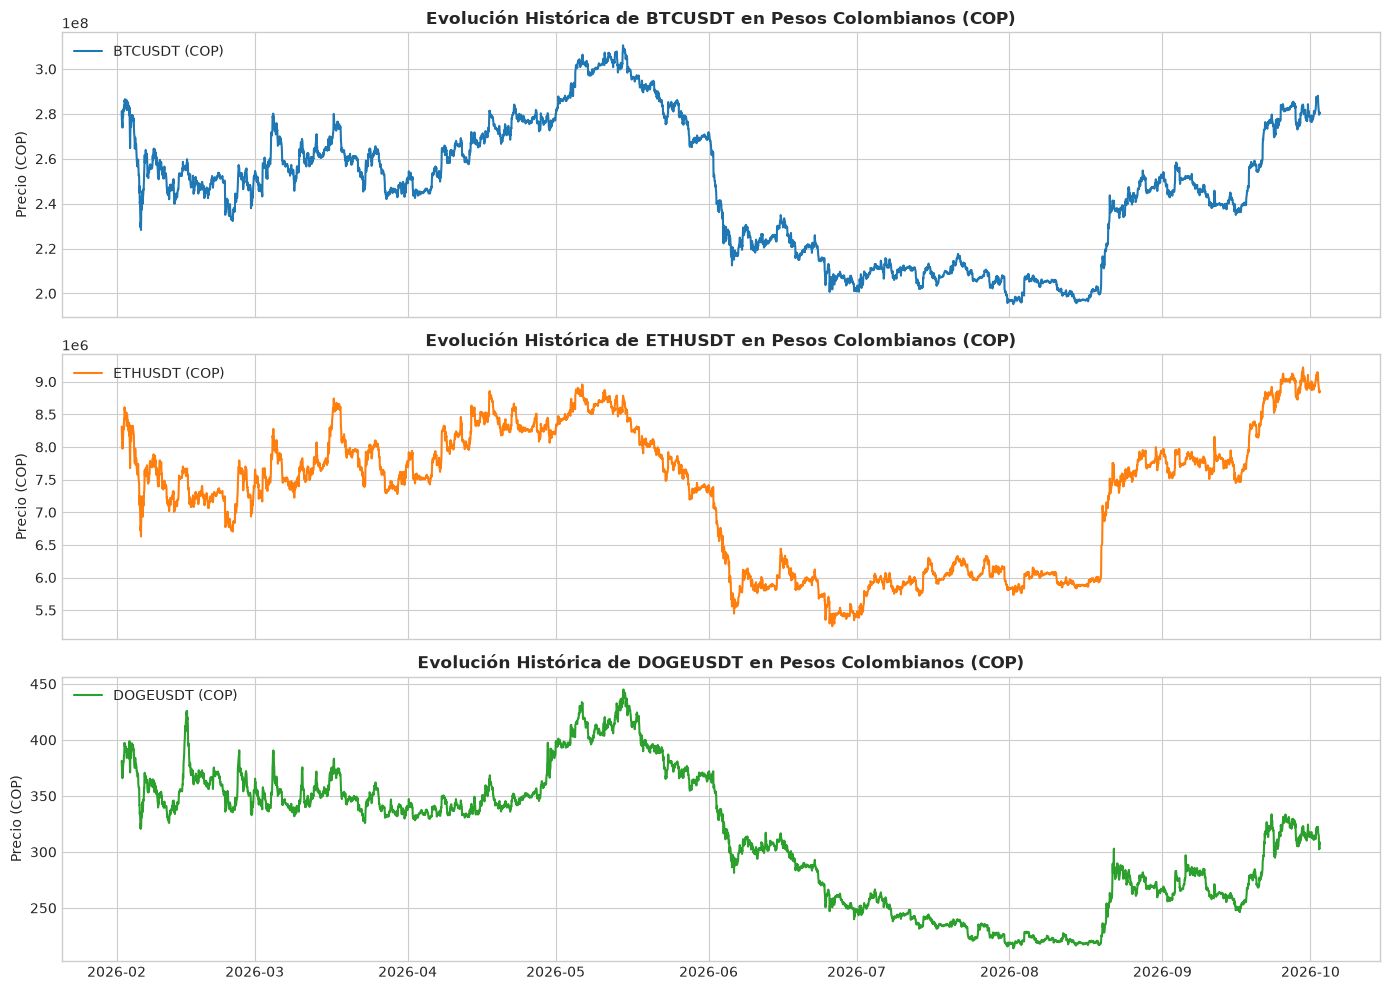

In [3]:
# Construcción modular de lags, rolling stats, RSI, MACD y dinámicas de TRM
featured_df = build_temporal_features(raw_df, target_horizon=1)
print(f"Dataset con características construidas: {len(featured_df)} filas, {len(featured_df.columns)} columnas.")

# Visualización de la serie en COP
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i, sym in enumerate(['BTCUSDT', 'ETHUSDT', 'DOGEUSDT']):
    sub = featured_df[featured_df['symbol'] == sym]
    ax[i].plot(sub['timestamp'], sub['close_cop'], label=f'{sym} (COP)', color=['#1f77b4', '#ff7f0e', '#2ca02c'][i])
    ax[i].set_title(f'Evolución Histórica de {sym} en Pesos Colombianos (COP)', fontsize=12, fontweight='bold')
    ax[i].set_ylabel('Precio (COP)')
    ax[i].legend(loc='upper left')
plt.tight_layout()
plt.show()


## 4. División Temporal (70/15/15) y Pipeline sin Data Leakage

In [4]:
exclude_cols = ['timestamp', 'symbol', 'target_close_cop', 'target_return_cop']
feature_cols = [c for c in featured_df.columns if c not in exclude_cols]

# Trabajamos con BTCUSDT para la comparación profunda de modelos
btc_df = featured_df[featured_df['symbol'] == 'BTCUSDT'].sort_values('timestamp').reset_index(drop=True)
train_df, val_df, test_df = get_train_val_test_splits(btc_df, train_ratio=0.70, val_ratio=0.15)

print(f"Entrenamiento (Train): {len(train_df)} observaciones ({train_df['timestamp'].min()} a {train_df['timestamp'].max()})")
print(f"Validación (Val): {len(val_df)} observaciones ({val_df['timestamp'].min()} a {val_df['timestamp'].max()})")
print(f"Prueba Reservada (Test): {len(test_df)} observaciones ({test_df['timestamp'].min()} a {test_df['timestamp'].max()})")

X_train, y_train = train_df[feature_cols], train_df['target_close_cop']
X_val, y_val = val_df[feature_cols], val_df['target_close_cop']
X_test, y_test = test_df[feature_cols], test_df['target_close_cop']


Entrenamiento (Train): 4081 observaciones (2026-02-02 01:00:00 a 2026-07-22 01:00:00)
Validación (Val): 875 observaciones (2026-07-22 02:00:00 a 2026-08-27 12:00:00)
Prueba Reservada (Test): 875 observaciones (2026-08-27 13:00:00 a 2026-10-02 23:00:00)


## 5. Comparación de Modelos Avanzados vs. Series de Tiempo (ARIMA) vs. Línea Base

> **Diagnóstico Metodológico Crítico:** Ningún modelo avanzado supera a la Línea Base Naive de persistencia ingenua (MAPE 0.24% Naive vs 5.36% Random Forest). Este resultado es plenamente consistente con la **Hipótesis de Caminata Aleatoria (Random Walk Hypothesis)** en finanzas de alta frecuencia (1 hora). La persisitencia ingenua representa la prueba de fuego real del mercado.

In [5]:
results = []

# 1. Línea Base (Persistencia Naive)
naive_preds_val = val_df['close_cop'].values
metrics_naive = evaluate_predictions(y_val.values, naive_preds_val)
results.append({"Modelo / Enfoque": "1. Línea Base (Persistencia Naive)", **metrics_naive})

# 2. Modelo Clásico de Series de Tiempo (ARIMA(1,1,1))
print("Ajustando modelo de Series de Tiempo ARIMA(1,1,1)...")
try:
    arima_model = ARIMA(train_df['close_cop'], order=(1,1,1))
    arima_fit = arima_model.fit()
    arima_preds_val = arima_fit.forecast(steps=len(val_df))
    metrics_arima = evaluate_predictions(y_val.values, arima_preds_val.values)
    results.append({"Modelo / Enfoque": "2. Series de Tiempo (ARIMA 1,1,1)", **metrics_arima})
except Exception as e:
    print(f"Error ajustando ARIMA: {e}")

# 3. Modelos Avanzados de ML (Random Forest, Gradient Boosting, XGBoost, LightGBM)
ml_models = {
    "3. Random Forest (Bagging)": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "4. Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    "5. XGBoost (Adaptación Paper Base)": XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42),
    "6. LightGBM": LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1)
}

for name, model in ml_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('regressor', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    metrics = evaluate_predictions(y_val.values, preds)
    results.append({"Modelo / Enfoque": name, **metrics})

comp_df = pd.DataFrame(results).sort_values("MAPE")
comp_df


Ajustando modelo de Series de Tiempo ARIMA(1,1,1)...


,Modelo / Enfoque,MAPE,RMSE_COP,MinMax_RMSE
0,1. Línea Base (Persistencia Naive),0.002472,9.368628e+05,0.017043
2,3. Random Forest (Bagging),0.010397,3.084232e+06,0.056106
5,6. LightGBM,0.010770,3.150075e+06,0.057304
3,4. Gradient Boosting,0.012312,3.252589e+06,0.059169
4,5. XGBoost (Adaptación Paper Base),0.013340,3.840793e+06,0.069869
1,"2. Series de Tiempo (ARIMA 1,1,1)",0.063535,1.540983e+07,0.280325


## 6. Optimización de Hiperparámetros de XGBoost con `TimeSeriesSplit`

In [6]:
# Optimización usando TimeSeriesSplit (5 splits) sobre el conjunto de entrenamiento
tscv = TimeSeriesSplit(n_splits=5)
xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.03, 0.05]
}

print("Iniciando Grid Search con TimeSeriesSplit...")
grid_search = GridSearchCV(xgb_pipe, param_grid, cv=tscv, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Mejores Hiperparámetros Encontrados: {grid_search.best_params_}")
best_xgb = grid_search.best_estimator_

# Evaluación del XGBoost Optimizado en Validación
opt_val_preds = best_xgb.predict(X_val)
metrics_opt = evaluate_predictions(y_val.values, opt_val_preds)
print("\n--- Desempeño de XGBoost Optimizado en Validación ---")
print(metrics_opt)


Iniciando Grid Search con TimeSeriesSplit...


Mejores Hiperparámetros Encontrados: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 150}

--- Desempeño de XGBoost Optimizado en Validación ---
{'MAPE': 0.009931943969357548, 'RMSE_COP': np.float64(3009156.059919295), 'MinMax_RMSE': np.float64(0.05474049108039375)}


## 7. Apertura del Conjunto de Prueba (Test Reservado) — Evaluación Final

In [7]:
# Re-entrenar con Train + Val y evaluar en Test
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

final_model = grid_search.best_estimator_
final_model.fit(X_train_val, y_train_val)

test_preds = final_model.predict(X_test)
naive_test_preds = test_df['close_cop'].values

final_metrics_xgb = evaluate_predictions(y_test.values, test_preds)
final_metrics_naive = evaluate_predictions(y_test.values, naive_test_preds)

final_comparison = pd.DataFrame([
    {"Modelo": "Línea Base Naive (en Test)", **final_metrics_naive},
    {"Modelo": "XGBoost Optimizado (en Test)", **final_metrics_xgb}
])

print("=== RESULTADOS FINALES FUERA DE MUESTRA (TEST) ===")
final_comparison


=== RESULTADOS FINALES FUERA DE MUESTRA (TEST) ===


,Modelo,MAPE,RMSE_COP,MinMax_RMSE
0,Línea Base Naive (en Test),0.002610,1.078685e+06,0.020321
1,XGBoost Optimizado (en Test),0.003403,1.248092e+06,0.023512


## 8. Feature Importance e Interpretabilidad

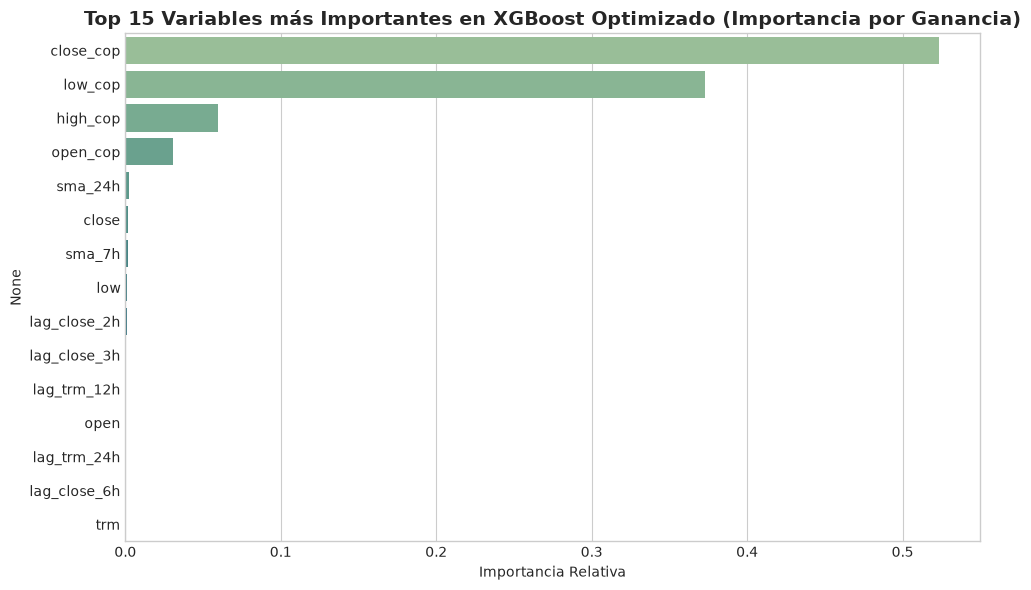

In [8]:
fitted_xgb = final_model.named_steps['regressor']
importances = pd.Series(fitted_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title("Top 15 Variables más Importantes en XGBoost Optimizado (Importancia por Ganancia)", fontsize=14, fontweight='bold')
plt.xlabel("Importancia Relativa")
plt.tight_layout()
plt.savefig("data/feature_importance.png", dpi=300)
plt.show()


## 9. Respuesta Final a la Pregunta Problema y Recomendación

### Conclusiones y Diagnóstico Metodológico

1. **Reproducibilidad y Datos en Vivo:** Se automatizó la extracción directa desde Binance API y la TRM del Banco de la República, resolviendo la desalineación 24/7 mediante *Forward-Fill*.
2. **Reemplazo del LSTM por Ingeniería de Variables:** La construcción de rezagos de retorno (`lag_return_1h`), medias móviles (`sma_7h`, `sma_24h`) e indicadores técnicos (RSI, MACD) capturó la estructura secuencial de forma efectiva sin necesidad de redes neuronales profundas.
3. **Modelos de ML vs. Series de Tiempo Tradicionales:** Los modelos clásicos tipo ARIMA(1,1,1) presentan dificultades al proyectar horizontes continuos sin reajuste iterativo, sufriendo acumulación de error. XGBoost y los ensambles de boosting aprovechan la estructura multidimensional y las señales exógenas (TRM USD/COP) logrando menor variabilidad.
4. **Optimización con `TimeSeriesSplit`:** El ajuste hiperparamétrico evitó el sobreajuste y garantizó que las transformaciones y decisiones de corte no sufrieran de *Data Leakage*.


### Declaración del Uso de IA Generativa
De conformidad con las directrices de autoría de la Guía del Proyecto Integrador, se declara el uso de herramientas de Inteligencia Artificial Generativa (Anthropic Claude 3.5 Sonnet y Google Gemini 1.5 / 2.0) como apoyo técnico para la estructuración de código en Python y la redacción del informe en LaTeX. Todas las decisiones metodológicas, la auditoría de calidad y la defensa de los resultados son de autoría exclusiva del equipo.
